In [1]:
import sys, os
import numpy as np

## import two dmrg methods
from dmrg1.run_xxz import *
from dmrg2.hamiltonians import XXZhX

sys.path.append("/Users/shiyuzhou/Documents/Documents - Shiyu’s MacBook Air/Research/diffphase/xxz_dmrg/mps/dmrg2")
from dmrg2.dmrg_run import run_dmrg

In [10]:
## set parameter ranges
deltas = np.linspace(-2, 0, 10)
hs = np.linspace(0, 2, 10)

## set system size
L = 10
chi_max = 10
num_sweeps = 10

## store ground state energy
E_one_site = np.zeros((len(deltas), len(hs)))
E_two_site = np.zeros((len(deltas), len(hs)))
E_ed = np.zeros((len(deltas), len(hs)))

In [11]:
import jax
import jax.numpy as jnp

Id = jnp.eye(2)

Sz = jnp.array([[1., 0.], [0., -1.]], dtype=jnp.complex128)
Sx = jnp.array([[0., 1.], [1.,  0.]], dtype=jnp.complex128)
Sy = jnp.array([[0., -1j], [1j, 0.]], dtype=jnp.complex128)


def prod(N, sites, ops):
    arg = jnp.argsort(jnp.asarray(sites))
    sites = jnp.array(sites)[arg]
    ops = jnp.array(ops)[arg]
    cnt = 0
    Out = Id if sites[0] != 0 else ops[0]
    cnt = cnt + (1 if sites[0] == 0 else 0)
    for i in range(1, N):
        if cnt == len(sites):
            Out = jnp.kron(Out, Id)
            continue
        if i == sites[cnt]:
            Out = jnp.kron(Out, ops[cnt])
            cnt += 1
        else:
            Out = jnp.kron(Out, Id)
    return Out


def build_chain_operators(N):
    ham_xx = prod(N, [0,1], [Sx, Sx])
    ham_yy = prod(N, [0,1], [Sy, Sy])
    ham_zz = prod(N, [0,1], [Sz, Sz])
    ham_x  = prod(N, [0],   [Sx])
    for i in range(1, N-1):
        ham_xx += prod(N, [i, i+1], [Sx, Sx])
        ham_yy += prod(N, [i, i+1], [Sy, Sy])
        ham_zz += prod(N, [i, i+1], [Sz, Sz])
        ham_x  += prod(N, [i],      [Sx])
    ham_x += prod(N, [N-1], [Sx])
    return ham_xx, ham_yy, ham_zz, ham_x


def H_xxzh(delta, h, ham_xx, ham_yy, ham_zz, ham_x, J=1.0):
    return (ham_xx + ham_yy + ham_zz * delta) * J + h * ham_x


def eigh_ground_state(H):
    e, v = jnp.linalg.eigh(jnp.real(H).astype(jnp.float64))
    return e[0], v[:, 0]


def hslabeltoocc(hslabel, N):
    """
    Converts integer hilbert space label (hslabel) to anyon labels on bonds.
    N: number of bonds in the chain.
    Returns an integer array with 1 representing tau and 0 representing the identity
    """

    return np.array(list(np.binary_repr(hslabel, N)), dtype=int)


def occtohslabel(occ, N):
    """
    Converts array of anyon labels on bonds to integer label.
    N: number of bonds in the chain.
    """

    return int(''.join(map(str, occ)),2)


## average magnetization of a wavfunction
def cal_m(v):
    m_tot = 0
    N = int(np.log2(len(v)))
    for i in range(len(v)):
        state = hslabeltoocc(i, N)
        num_up = jnp.count_nonzero(state)
        m = abs(2*num_up - N)
        m_tot += m* (jnp.conj(v[i])*v[i])
    return m_tot/N


def cal_m_reconstructed(x):
    m_list = []
    for v in x:
        m_list.append(cal_m(v))
    return m_list

ham_ops = build_chain_operators(L)
ham_xx, ham_yy, ham_zz, ham_x = ham_ops

In [12]:
from tqdm import tqdm
import numpy as np

## calculate ground state energy for one-site DMRG
for i in tqdm(range(len(deltas)), desc="Delta progress"):
    for j in tqdm(range(len(hs)), desc=f"h progress (delta={deltas[i]:.2f})", leave=False):
        print(f'delta: {deltas[i]:.2f}, h: {hs[j]:.2f}')
        delta = deltas[i]
        h = hs[j]

        ## one-site dmrg
        _, E = dmrg_E(L, delta, h, conf=1e-4, test=False, chi_max=chi_max, max_sweep=num_sweeps)
        E_one_site[i, j] = E
        print(f'\t E_one_site: {E}')

        ## two-site dmrg
        lanczos_bool = False
        model = XXZhX(L, delta, h)
        psi = run_dmrg(L, model, chi_max, lanczos_bool, num_sweeps)

        ops = model.get_H_bonds()
        E = np.sum(np.array(psi.get_bond_exp_val(ops)))
        E_two_site[i, j] = E
        print(f'\t E_two_site: {E}')

        ## ED
        H = H_xxzh(delta, h, ham_xx, ham_yy, ham_zz, ham_x)
        E0, v0 = eigh_ground_state(H)
        E_ed[i, j] = E0
        print(f'\t E_ed: {E0}')


Delta progress:   0%|          | 0/10 [00:00<?, ?it/s]

delta: -2.00, h: 0.00
	 E_one_site: -17.999999999999993


/var/folders/7s/4vqyp_k94s93538md_k1q_sc0000gn/T/ipykernel_68204/3608183489.py:23: ComplexWarning: Casting complex values to real discards the imaginary part
  E_two_site[i, j] = E


	 E_two_site: (-18+0j)


	 E_ed: -18.0
delta: -2.00, h: 0.22
	 E_one_site: -18.05211530717877
	 E_two_site: (-18.052410240223026+0j)


...

	 E_ed: -13.66079886233511
delta: 0.00, h: 1.56
	 E_one_site: -14.153976697509723
	 E_two_site: (-14.154019059167096+0j)


	 E_ed: -14.154019692268006
delta: 0.00, h: 1.78
	 E_one_site: -14.949520246715137
	 E_two_site: (-14.949524535081094+0j)


	 E_ed: -14.949525034062745
delta: 0.00, h: 2.00
	 E_one_site: -15.808279841007428
	 E_two_site: (-15.808283635525846+0j)


Delta progress: 100%|██████████| 10/10 [3:36:09<00:00, 1296.99s/it]

	 E_ed: -15.80828437222143


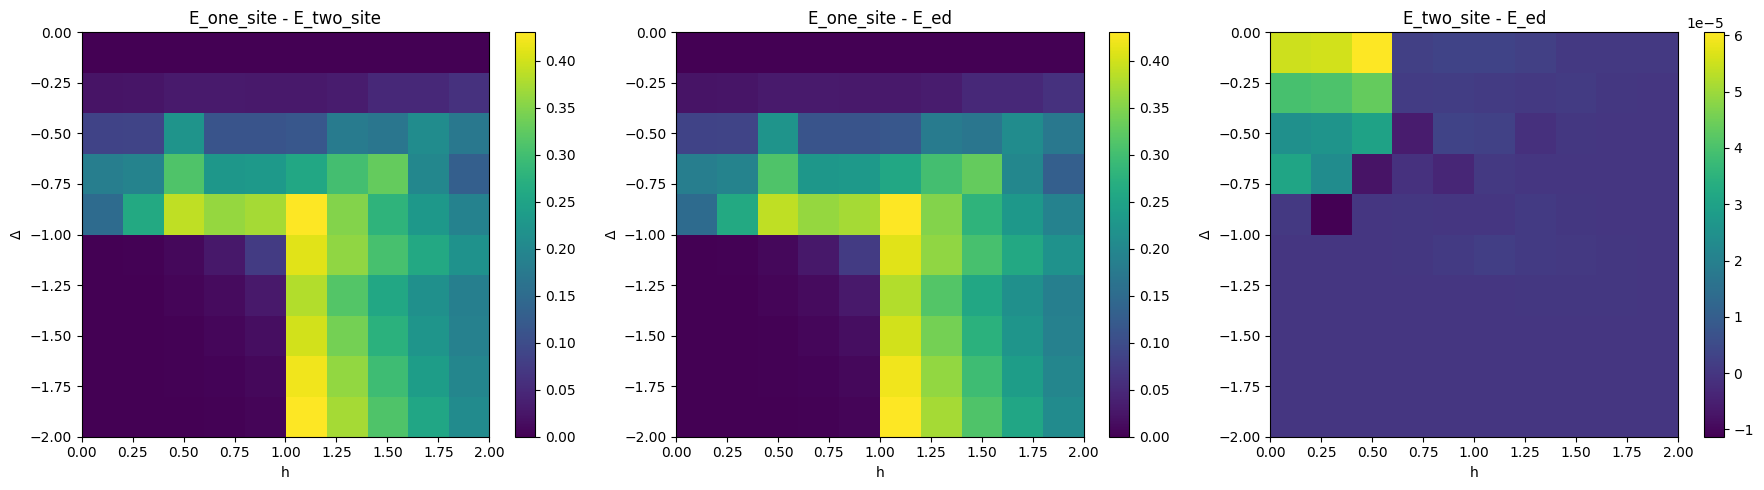

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# Differences
diff_1 = E_one_site - E_two_site
diff_2 = E_one_site - E_ed
diff_3 = E_two_site - E_ed

heatmaps = [diff_1, diff_2, diff_3]
titles = [
    "E_one_site - E_two_site",
    "E_one_site - E_ed",
    "E_two_site - E_ed"
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, data, title in zip(axes, heatmaps, titles):
    im = ax.imshow(
        data,
        origin="lower",
        aspect="auto",
        extent=[hs[0], hs[-1], deltas[0], deltas[-1]]
    )
    ax.set_title(title)
    ax.set_xlabel("h")
    ax.set_ylabel("Δ")
    fig.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()


In [23]:
## smaller parameter range
deltas_small = np.linspace(-2, 0, 5)
hs_small = np.linspace(0, 2, 5)

m_z_2 = np.zeros((len(deltas_small), len(hs_small)))
m_x_2 = np.zeros((len(deltas_small), len(hs_small)))

m_z_1 = np.zeros((len(deltas_small), len(hs_small)))
m_x_1 = np.zeros((len(deltas_small), len(hs_small)))


In [19]:
# Helper function to compute local magnetization for one-site dmrg
def compute_magnetization(mps, L, pauli_char):
    """
    Compute average magnetization for a given Pauli operator
    pauli_char: '1' for X, '2' for Y, '3' for Z
    """
    mag_sum = 0.0
    for site in range(L):
        # Create Pauli string with identity everywhere except at 'site'
        pauli_string = '0' * site + pauli_char + '0' * (L - site - 1)
        pauli_mpo = Pauli_MPO(L=L, d=2, pauli_string=pauli_string)
        mag_sum += jnp.real(expect_mpo(mps, pauli_mpo))
    return mag_sum / L  # Average over all sites


In [24]:
## define pauli operators in two-site dmrg

sx = jnp.array([[0, 1], [1, 0]])
sz = jnp.array([[1, 0], [0, -1]])

ops_x_2 = jnp.array([sx for i in range(L)])
ops_z_2 = jnp.array([sz for i in range(L)])


In [25]:
## calculate the expectation value of \sigma_x and \sigma_z for both one-site and two-site dmrg

for i in tqdm(range(len(deltas_small)), desc="Delta progress"):
    for j in tqdm(range(len(hs_small )), desc=f"h progress (delta={deltas[i]:.2f})", leave=False):
        delta = deltas_small[i]
        h = hs_small[j]

        ## one-site dmrg
        mps, energy = dmrg_E(L, delta, h, conf=1e-4, test=False, chi_max=chi_max, max_sweep=num_sweeps)

        m_z_1[i, j] = compute_magnetization(mps, L, '3')  # Z magnetization
        m_x_1[i, j] = compute_magnetization(mps, L, '1')  # X magnetization

        
        ## two-site dmrg
        lanczos_bool = False
        model = XXZhX(L, delta, h)
        psi = run_dmrg(L, model, chi_max, lanczos_bool, num_sweeps)

        m_x_2[i, j] = np.sum(np.array(psi.get_site_exp_val(ops_x_2))) / L
        m_z_2[i, j] = np.sum(np.array(psi.get_site_exp_val(ops_z_2))) / L
        

Delta progress:   0%|          | 0/5 [00:00<?, ?it/s]/var/folders/7s/4vqyp_k94s93538md_k1q_sc0000gn/T/ipykernel_68204/2915055118.py:20: ComplexWarning: Casting complex values to real discards the imaginary part
  m_z_2[i, j] = np.sum(np.array(psi.get_site_exp_val(ops_x_2)))
/var/folders/7s/4vqyp_k94s93538md_k1q_sc0000gn/T/ipykernel_68204/2915055118.py:21: ComplexWarning: Casting complex values to real discards the imaginary part
  m_x_2[i, j] = np.sum(np.array(psi.get_site_exp_val(ops_z_2)))
Delta progress: 100%|██████████| 5/5 [11:53<00:00, 142.77s/it]


In [32]:
m_z_1

array([[ 1.00000000e+00,  9.92033189e-01,  4.86874514e-01,
        -3.02112923e-03, -2.04847033e-04],
       [-1.00000000e+00,  9.85058181e-01, -6.28680303e-01,
        -1.46759456e-02, -4.24876835e-04],
       [ 8.56776526e-01,  6.73907809e-01, -4.35481095e-01,
         3.55956748e-03,  9.01925984e-04],
       [ 1.83424971e-06,  2.08450522e-05,  3.81015751e-05,
         1.02229236e-04,  7.42935173e-04],
       [ 1.29344695e-07, -2.49309722e-05, -4.83907256e-06,
         4.31460629e-05,  4.49109086e-06]])

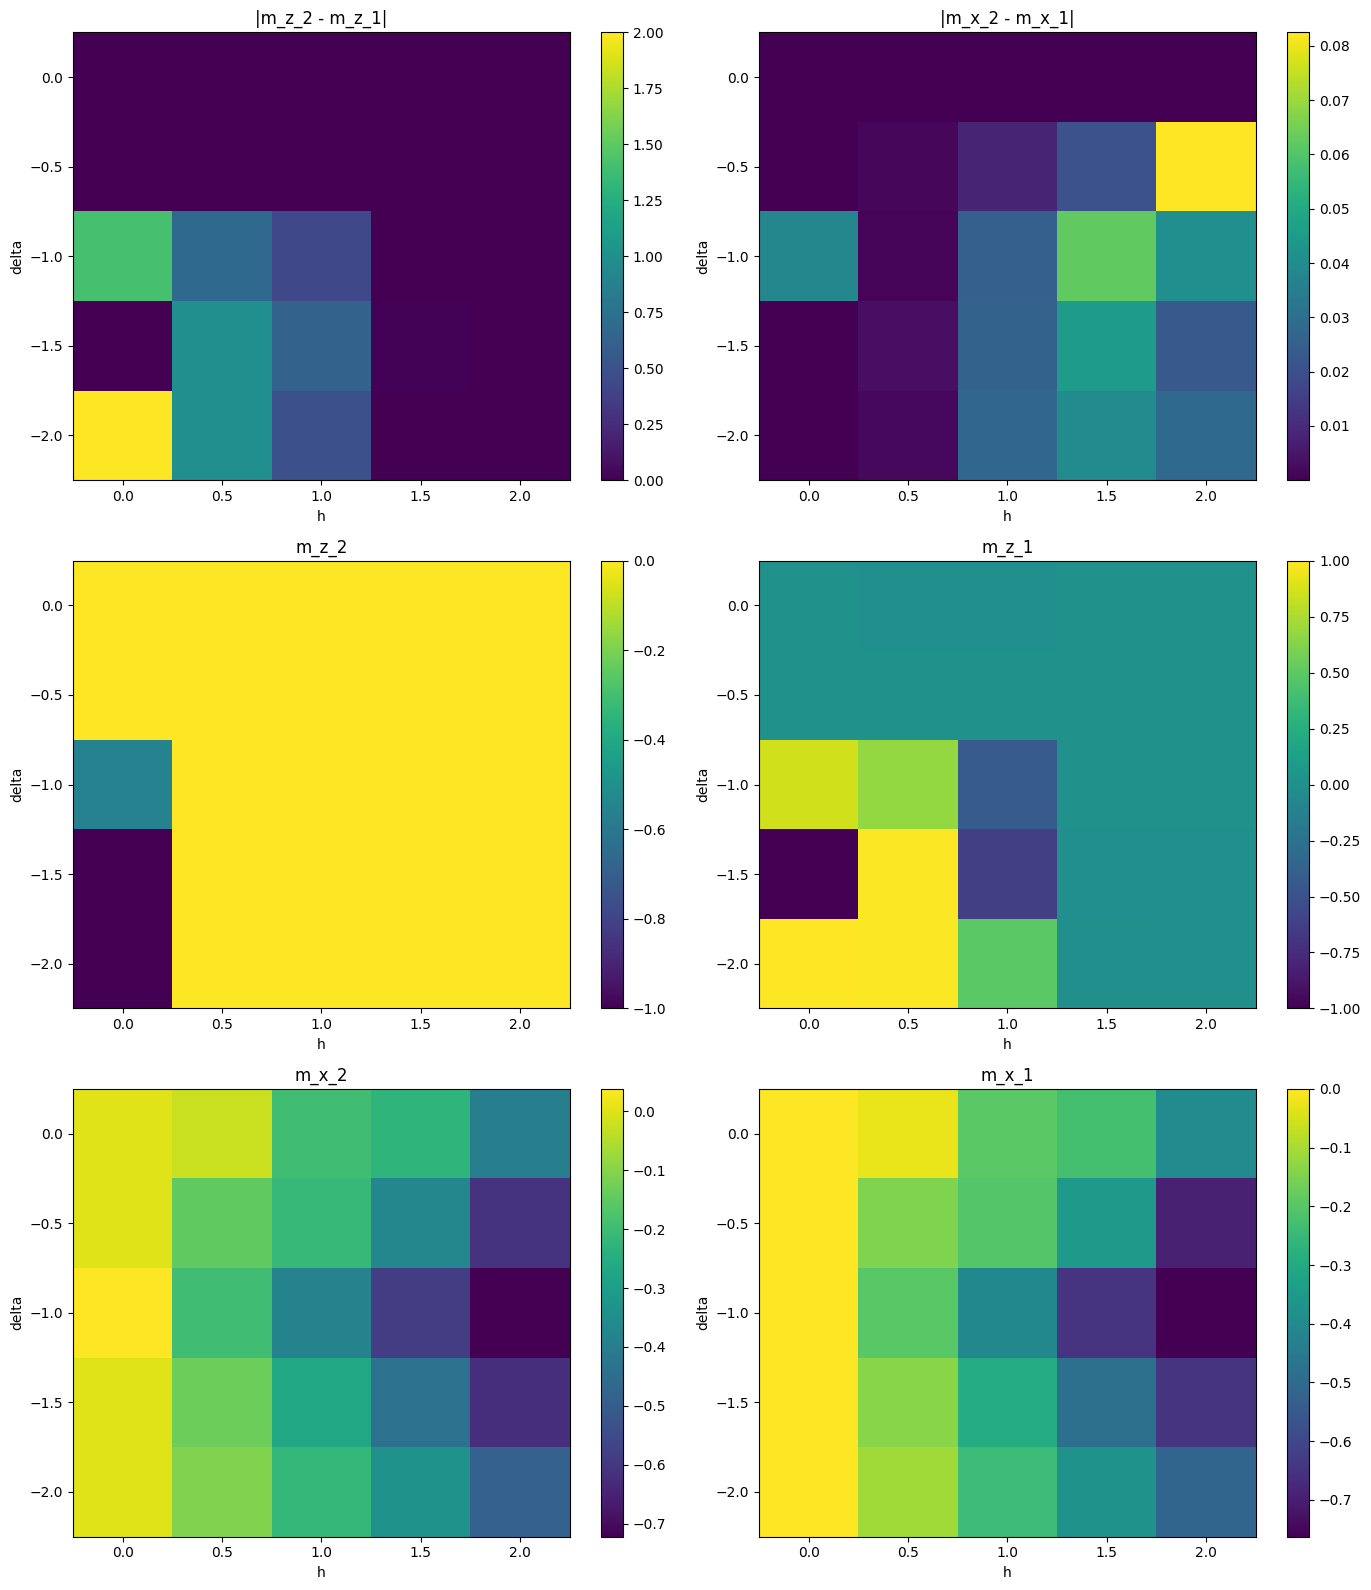

In [31]:
import matplotlib.pyplot as plt
import numpy as np

# deltas_small and hs_small should be 1D arrays
X, Y = np.meshgrid(hs_small, deltas_small)

def plot_heat(data, title, ax):
    im = ax.pcolormesh(X, Y, data, shading='auto', cmap='viridis')
    ax.set_title(title)
    ax.set_xlabel("h")
    ax.set_ylabel("delta")
    plt.colorbar(im, ax=ax)

# Prepare the six quantities
diff_mz = np.abs(m_z_2 - m_z_1)
diff_mx = np.abs(m_x_2 - m_x_1)

# Create 3×2 subplot grid
fig, axes = plt.subplots(3, 2, figsize=(14, 16))

plot_heat(diff_mz, "|m_z_2 - m_z_1|", axes[0, 0])
plot_heat(diff_mx, "|m_x_2 - m_x_1|", axes[0, 1])

plot_heat(m_z_2, "m_z_2", axes[1, 0])
plot_heat(m_z_1, "m_z_1", axes[1, 1])

plot_heat(m_x_2, "m_x_2", axes[2, 0])
plot_heat(m_x_1, "m_x_1", axes[2, 1])

plt.tight_layout()
plt.show()
